# FRBlip quick start

In [1]:
# Necessary libraries.
import math as math
from astropy import units as u
import numpy as np
import pymp
import frblip as frb
import matplotlib.pyplot as plt

In [2]:
"""import joblib

data_bingo = joblib.load('/home/lazarolima/frblip/frblip/data/bingo.pkl')
data_naked_horn = joblib.load('/home/lazarolima/frblip/frblip/data/naked_horn.pkl')
data_mirror_4m = joblib.load('/home/lazarolima/frblip/frblip/data/mirror_4m.pkl')
data_mirror_6m = joblib.load('/home/lazarolima/frblip/frblip/data/mirror_6m.pkl')
print(data_bingo)
print(data_naked_horn)
print(data_mirror_4m)
print(data_mirror_6m)"""


"import joblib\n\ndata_bingo = joblib.load('/home/lazarolima/frblip/frblip/data/bingo.pkl')\ndata_naked_horn = joblib.load('/home/lazarolima/frblip/frblip/data/naked_horn.pkl')\ndata_mirror_4m = joblib.load('/home/lazarolima/frblip/frblip/data/mirror_4m.pkl')\ndata_mirror_6m = joblib.load('/home/lazarolima/frblip/frblip/data/mirror_6m.pkl')\nprint(data_bingo)\nprint(data_naked_horn)\nprint(data_mirror_4m)\nprint(data_mirror_6m)"

In [3]:
# BEGIN OF INPUTS
# Input file names
input_main_name   = 'bingo'
input_array_name  = 'mirror_4m'
input_altaz_file = '/home/lazarolima/frblip/examples/altaz/outrigger_3direc.dat'

# Output file names
output_counter    = '/home/lazarolima/frblip/Script_Gabriel/counter_frb.dat'
output_details    = '/home/lazarolima/frblip/Script_Gabriel/frb_details.dat'

# Number of days and cpus
cpus = 6
days = 365

# Beams information 
num_stations  = 1
  
# Detection criteria
minimum_snr                   = 2.0
detection_snr                 = 5.0
localization_total_snr        = 3.0
localization_per_baseline_snr = 2.0

# Cosmology and observarion
spectral_index = -1.5     # Spectral Index distribution.
zmax           = 6.0     # z max for FRB in cosmological FRBs
dec            = (-30.0, 10.0) # Survey dec

# CREATE THE TELESCOPES DICTIONARY AND SETUP THE POSITIONS AND OFFSETS
altaz = np.loadtxt(input_altaz_file)
telescopes = {}
telescopes['MAIN'] = frb.telescope(input_main_name, system_temperature=70*u.K)
telescopes['ARRAY'] = frb.telescope(input_array_name, system_temperature=70*u.K, alt=altaz[:,0]*u.deg,az=altaz[:,1]*u.deg)

"""# SETUP THE INTF KEYS AND THE AMOUNT OF INTF
observ_keys = ['MAIN']
inter_keys = []
inter_indices = []"""

"""# SETUP THE INTF KEYS AND THE AMOUNT OF INTF
observ_keys = ['MAIN', 'ARRAY', 'INTF_MAIN_ARRAY']
inter_keys = ['INTF_MAIN_ARRAY']
inter_indices = [2]"""

# SETUP THE INTF KEYS AND THE AMOUNT OF INTF
observ_keys   = ['MAIN', 'ARRAY', 'INTF_ARRAY_ARRAY', 'INTF_MAIN_ARRAY']
inter_keys    = ['INTF_ARRAY_ARRAY', 'INTF_MAIN_ARRAY']
inter_indices = [2, 3]

total_observ = len(observ_keys)

# SETUP SEED    
counter_file = np.loadtxt(output_counter)
if counter_file.T[0].size == 0:
    seed_starter = 0
else:
    seed_starter = int(counter_file.T[0].sum(0))
    
print('The seed starter of this run is ' + str(seed_starter))

# MULTIPLIERS SETUP
# multi_intf_array = (np.math.factorial(num_stations) / (np.math.factorial(num_stations - 2) * 2))
multi_intf_array = 1

main_location = telescopes['MAIN'].location
                                

The seed starter of this run is 10


## Create a mock of Cosmic Bursts

In [4]:
# Shared variables for accumulating results across all processes
shared_num_candidates = pymp.shared.dict()
shared_num_detection = pymp.shared.dict()
shared_num_localization_1 = pymp.shared.dict()
shared_num_localization_2 = pymp.shared.dict()
shared_frb_info = pymp.shared.dict()

with pymp.Parallel(cpus) as p:
    for i in p.range(days):
        #np.random.seed(i + seed_starter)

        random_gen = np.random.RandomState(i + seed_starter)
        
        # Local variables for this process
        local_num_candidates = 0
        local_num_detection = 0
        local_num_localization_1 = 0
        local_num_localization_2 = 0

        candidates = []
        frb_candidates = []

        local_frb_info = {}
        frb_info = {}

        mock = frb.blips(random_state=random_gen, zmax=zmax, spectral_index=spectral_index, dec_range=dec, duration=1)
        mock.observe(telescopes, verbose=False, location=main_location)
        mock.interferometry('MAIN', 'ARRAY', overwrite=True)
        mock.interferometry('ARRAY', 'ARRAY', overwrite=True)

        # Dictionary for storing information about the current day
        frb_info[i] = []

        # Creating a dictionary for signal to noise ratio
        snr_values = {}
        for key in observ_keys:
            snr_values[key] = mock.signal_to_noise(key, todense=True)

        for j in range(total_observ):
            key = observ_keys[j]  
            where = np.unique(np.where(snr_values[key] > minimum_snr)[0])
            if np.array(where).size > 0:
                for k in range(np.array(where).size):
                    frb_candidates.append(where[k])

        num_candidates_day = len(list(set(frb_candidates)))
        if num_candidates_day == 0:
            continue

        local_num_candidates += num_candidates_day
        catalog_frblip = mock.catalog()
        for k in range(num_candidates_day):
            frb_index = list(set(frb_candidates))[k]
            # Creating a dictionary for parameters of interest
            frb_dic = {
                'day': i,
                'no': frb_index,
                'redshift': mock.redshift[frb_index],
                'log_luminosity': mock.log_luminosity[frb_index].value,
                'alt': mock['MAIN'].altaz.alt.value[frb_index],
                'az': mock['MAIN'].altaz.az.value[frb_index],
                'DM': mock.dispersion_measure[frb_index].value,
                'IGM_DM': mock.igm_dm[frb_index].value,
                'Host_DM': mock.host_dm[frb_index].value,
                'Extragalactic_DM': mock.extra_galactic_dm[frb_index].value,
                'right_ascension': catalog_frblip['right_ascension'][k],
                'declination': catalog_frblip['declination'][k],
                'detected': 0,  
                'in_1_baseline': 0, 
                'in_2_baselines': 0, 
                'by_BINGO': 0
            }

            frb_info[i].append(frb_dic)

        sum_observ = np.zeros(num_candidates_day)

        for j in range(num_candidates_day):
            for k in range(total_observ):
                key = observ_keys[k]
                frb_index = list(set(frb_candidates))[j]
                snr_array = np.array(snr_values[key])
                if k == 0:
                    sum_observ[j] += (snr_array[frb_index]**2).sum(0)
                elif k == 1:
                    sum_observ[j] += num_stations * (snr_array[frb_index]**2).sum(0)
                elif k == 2:
                    sum_observ[j] += multi_intf_array * (snr_array[frb_index]**2).sum(0)
                else:
                    for l in range(28):
                        sum_observ[j] += num_stations * (snr_array[frb_index, l]**2).sum(0)

            # Update if FRB was detected
            if np.sqrt(sum_observ[j]) > detection_snr:
                local_num_detection += 1
                frb_info[i][j]['detected'] = 1

        sum_intf = np.zeros(num_candidates_day)

        for j in range(num_candidates_day):
            count_localization = 0
            main_contribution = 0
            for k in inter_indices:
                key = observ_keys[k]
                frb_index = list(set(frb_candidates))[j]
                snr_array = np.array(snr_values[key])
                if k == 2:
                    sum_intf[j] += multi_intf_array * (snr_array[frb_index]**2).sum(0)
                    count_localization += ((snr_array[frb_index]) > localization_per_baseline_snr).sum()
                else:
                    for l in range(28):
                        sum_intf[j] += num_stations * (snr_array[frb_index, l]**2).sum(0)
                        count_localization += ((snr_array[frb_index, l]) > localization_per_baseline_snr).sum()
                        if ((snr_array[frb_index, l]) > localization_per_baseline_snr).sum() >= 1:
                            main_contribution += 1

            # Updates location and detection information in 1 or 2 baselines
            if (np.sqrt(sum_intf[j]) > localization_total_snr) and (np.sqrt(sum_observ[j]) > detection_snr) and (count_localization >= 1):
                local_num_localization_1 += 1
                frb_info[i][j]['in_1_baseline'] = 1

            if (np.sqrt(sum_intf[j]) > localization_total_snr) and (np.sqrt(sum_observ[j]) > detection_snr) and (count_localization >= 2):
                local_num_localization_2 += 1
                frb_info[i][j]['in_2_baselines'] = 1

            if (np.sqrt(sum_intf[j]) > localization_total_snr) and (np.sqrt(sum_observ[j]) > detection_snr) and (count_localization >= 1) and (main_contribution >= 1):
                frb_info[i][j]['by_BINGO'] = 1

        local_frb_info[i] = frb_info[i]

        # Update shared variables with local results
        with p.lock:
            shared_num_candidates[i] = local_num_candidates
            shared_num_detection[i] = local_num_detection
            shared_num_localization_1[i] = local_num_localization_1
            shared_num_localization_2[i] = local_num_localization_2
            shared_frb_info[i] = local_frb_info

# After the parallel section, aggregate results
total_num_candidates = sum(shared_num_candidates.values())
total_num_detection = sum(shared_num_detection.values())
total_num_localization_1 = sum(shared_num_localization_1.values())
total_num_localization_2 = sum(shared_num_localization_2.values())

# Combine all FRB info
frb_info = {}
for day_info in shared_frb_info.values():
    frb_info.update(day_info)
    

/home/lazarolima/.conda/envs/env_frblip/lib/python3.10/site-packages/xarray/core/concat.py:504: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  common_dims = tuple(pd.unique([d for v in vars for d in v.dims]))
/home/lazarolima/.conda/envs/env_frblip/lib/python3.10/site-packages/xarray/core/concat.py:504: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  common_dims = tuple(pd.unique([d for v in vars for d in v.dims]))
/home/lazarolima/.conda/envs/env_frblip/lib/python3.10/site-packages/xarray/core/concat.py:504: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  common_dims = tuple(pd.unique([d for v in vars for d in v.dims]))
/home/lazarolima/.conda/envs/env_frblip/lib/python3.10/site-p

In [5]:
with open(output_counter, "w") as text_file_counts:
    text_file_counts.write("") 
    print('Number of candidates: ' + str(total_num_candidates) + '\n')
    print('Number of detection: ' + str(total_num_detection) + '\n')
    print('Number of localization in at least 1 point: ' + str(total_num_localization_1) + '\n')
    print('Number of localization in at least 2 points: ' + str(total_num_localization_2) + '\n')
    text_file_counts.write(str(days) + "\t" + str(total_num_candidates) + "\t" + str(total_num_detection) +  "\t" +
                           str(total_num_localization_1) + "\t" + str(total_num_localization_2) + "\n")

Number of candidates: 106

Number of detection: 49

Number of localization in at least 1 point: 13

Number of localization in at least 2 points: 13



In [6]:
with open(output_details, "w") as text_file_frb:
    text_file_frb.write("")  
    for dia, frbs in frb_info.items():
        for frb in frbs:
            text_file_frb.write(
                f"{frb['day']} \t {frb['no']} \t {frb['redshift']:.2f} \t {frb['log_luminosity']:.2f} \t "
                f"{frb['alt']:.2f} \t {frb['az']:.2f} \t {frb['DM']:.2f} \t {frb['detected']} \t "
                f"{frb['in_1_baseline']} \t {frb['in_2_baselines']} \t {frb['by_BINGO']} \n "
            )

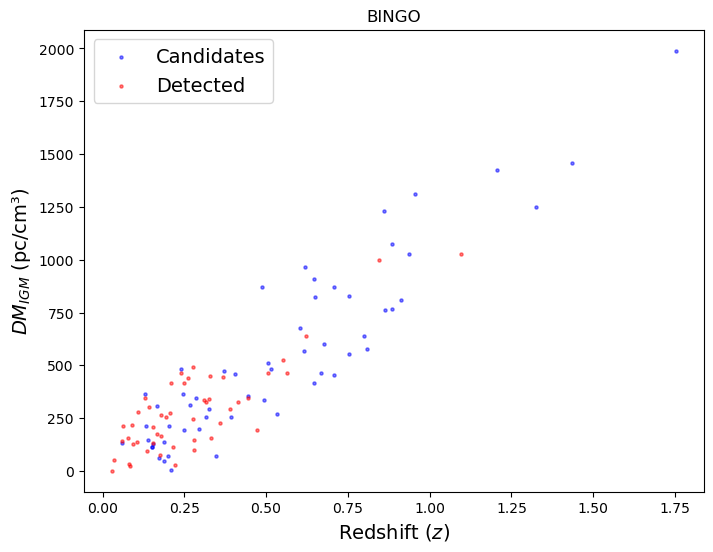

In [7]:
# Lists to store DM_IGM and z values ​​for candidates and detected
z_igm_candidates = []
dm_igm_candidates = []
z_igm_detected = []
dm_igm_detected = []

for dia, frbs in frb_info.items():
    for frb in frbs:
        if frb['detected'] == 1:
            z_igm_detected.append(frb['redshift'])
            dm_igm_detected.append(frb['IGM_DM'])
        else:
            z_igm_candidates.append(frb['redshift'])
            dm_igm_candidates.append(frb['IGM_DM'])

plt.figure(figsize=(8, 6))
plt.scatter(z_igm_candidates, dm_igm_candidates, color='blue', label='Candidates', s=5, marker='o', alpha=0.5)
plt.scatter(z_igm_detected, dm_igm_detected, color='red', label='Detected', s=5, marker='o', alpha=0.5)
plt.xlabel('Redshift ($z$)', fontsize=14)
plt.ylabel('$DM_{IGM}$ (pc/cm³)', fontsize=14)
plt.title(label='BINGO')
plt.legend(fontsize=14)
plt.grid(False)
plt.savefig('figures/mock_DM_IGM_bingo.png', dpi=600)
plt.show()


In [8]:
# Storage the data
data_IGM_candidates = np.column_stack((z_igm_candidates, dm_igm_candidates))
np.savetxt('data_sim/DM_IGM_candidates_bingo_alpha=-1.5_5yrs.txt', data_IGM_candidates, fmt='%f', delimiter='\t', header='z_cadidates \t DM_IGM_candidates')

data_IGM_detected = np.column_stack((z_igm_detected, dm_igm_detected))
np.savetxt('data_sim/DM_IGM_detected_bingo_alpha=-1.5_5yrs.txt', data_IGM_detected, fmt='%f', delimiter='\t', header='z_decected \t DM_IGM_detected')

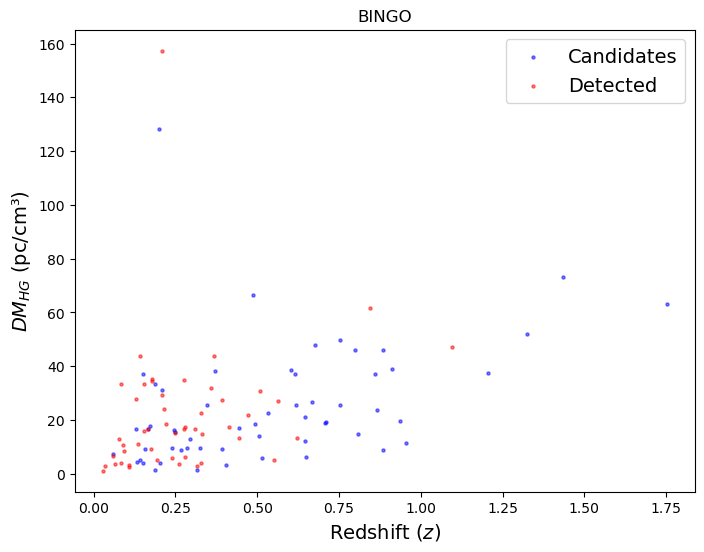

In [9]:
# Lists to store DM_Host and z values ​​for candidates and detected
z_host_candidates = []
dm_host_candidates = []
z_host_detected = []
dm_host_detected = []

for dia, frbs in frb_info.items():
    for frb in frbs:
        if frb['detected'] == 1:
            z_host_detected.append(frb['redshift'])
            dm_host_detected.append(frb['Host_DM'])
        else:
            z_host_candidates.append(frb['redshift'])
            dm_host_candidates.append(frb['Host_DM'])

plt.figure(figsize=(8, 6))
plt.scatter(z_host_candidates, dm_host_candidates, color='blue', label='Candidates', s=5, marker='o', alpha=0.5)
plt.scatter(z_host_detected, dm_host_detected, color='red', label='Detected', s=5, marker='o', alpha=0.5)
plt.xlabel('Redshift ($z$)', fontsize=14)
plt.ylabel('$DM_{HG}$ (pc/cm³)', fontsize=14)
plt.title(label='BINGO')
plt.legend(fontsize=14)
plt.grid(False)
plt.savefig('figures/mock_DM_HG_bingo.png', dpi=600)
plt.show()


In [10]:
# Storage the data
data_host_candidates = np.column_stack((z_host_candidates, dm_host_candidates))
np.savetxt('data_sim/DM_host_candidates_bingo_alpha=-1.5_5yrs.txt', data_host_candidates, fmt='%f', delimiter='\t', header='z_cadidates \t DM_host_candidates')

data_host_detected = np.column_stack((z_host_detected, dm_host_detected))
np.savetxt('data_sim/DM_host_detected_bingo_alpha=-1.5_5yrs.txt', data_host_detected, fmt='%f', delimiter='\t', header='z_decected \t DM_host_detected')

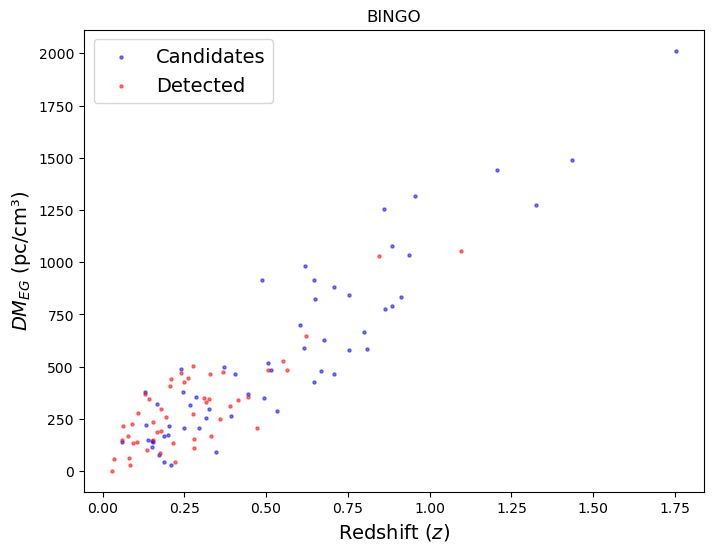

In [11]:
# Lists to store DM_EG and z values ​​for candidates and detected
z_EG_candidates = []
dm_EG_candidates = []
z_EG_detected = []
dm_EG_detected = []

for dia, frbs in frb_info.items():
    for frb in frbs:
        if frb['detected'] == 1:
            z_EG_detected.append(frb['redshift'])
            dm_EG_detected.append(frb['Extragalactic_DM'])
        else:
            z_EG_candidates.append(frb['redshift'])
            dm_EG_candidates.append(frb['Extragalactic_DM'])

plt.figure(figsize=(8, 6))
plt.scatter(z_EG_candidates, dm_EG_candidates, color='blue', label='Candidates', s=5, marker='o', alpha=0.5)
plt.scatter(z_EG_detected, dm_EG_detected, color='red', label='Detected', s=5, marker='o', alpha=0.5)
plt.xlabel('Redshift ($z$)', fontsize=14)
plt.ylabel('$DM_{EG}$ (pc/cm³)', fontsize=14)
plt.title(label='BINGO')
plt.legend(fontsize=14)
plt.grid(False)
plt.savefig('figures/mock_DM_EG_bingo.png', dpi=600)
plt.show()

In [12]:
# Storage the data
data_EG_candidates = np.column_stack((z_EG_candidates, dm_EG_candidates))
np.savetxt('data_sim/DM_EG_candidates_bingo_alpha=-1.5_5yrs.txt', data_EG_candidates, fmt='%f', delimiter='\t', header='z_cadidates \t DM_EG_candidates')

data_EG_detected = np.column_stack((z_EG_detected, dm_EG_detected))
np.savetxt('data_sim/DM_EG_detected_bingo_alpha=-1.5_5yrs.txt', data_EG_detected, fmt='%f', delimiter='\t', header='z_decected \t DM_EG_detected')

In [13]:
from astropy.coordinates import SkyCoord
from astropy.visualization import astropy_mpl_style
import astropy.units as u

plt.style.use(astropy_mpl_style)


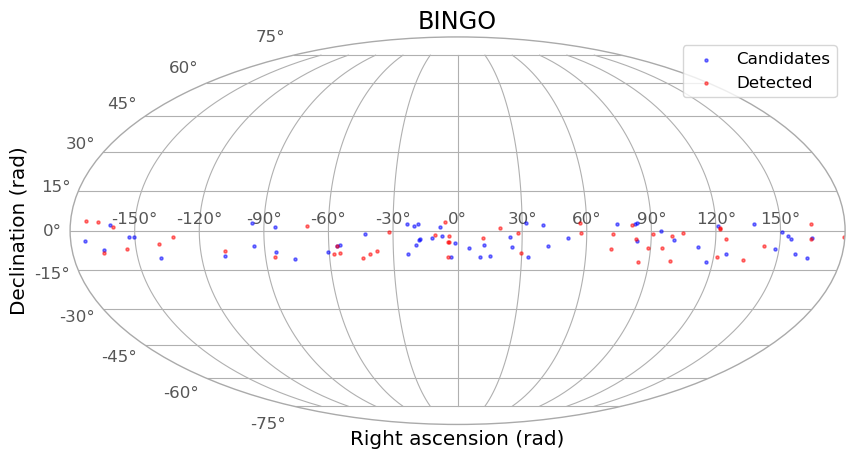

In [33]:
# Lists to store ra and dec values ​​for candidates and detected
ra_candidates = []
dec_candidates = []
ra_detected = []
dec_detected = []

for dia, frbs in frb_info.items():
    for frb in frbs:
        if frb['detected'] == 1:
            ra_detected.append(frb['right_ascension'])
            dec_detected.append(frb['declination'])
        else:
            ra_candidates.append(frb['right_ascension'])
            dec_candidates.append(frb['declination'])

candidates_coord = SkyCoord(ra=ra_candidates, dec=dec_candidates, unit=(u.hourangle, u.deg), frame='icrs')
detected_coord = SkyCoord(ra=ra_detected, dec=dec_detected, unit=(u.hourangle, u.deg), frame='icrs')

candidates_coord_ra = candidates_coord.ra.wrap_at(180 * u.deg).radian
candidates_coord_dec = candidates_coord.dec.radian
detected_coord_ra = detected_coord.ra.wrap_at(180 * u.deg).radian
detected_coord_dec = detected_coord.dec.radian


plt.figure(figsize=(10, 6))
plt.subplot(111, projection='mollweide')
plt.scatter(candidates_coord_ra, candidates_coord_dec, color='blue', label='Candidates', s=5, alpha=0.5)
plt.scatter(detected_coord_ra, detected_coord_dec, color='red', label='Detected', s=5, alpha=0.5)
plt.xlabel('Right ascension (rad)')
plt.ylabel('Declination (rad)')
plt.title(label='BINGO')
plt.legend()
plt.grid(True)
plt.savefig('figures/sky_map_bingo.png', dpi=600)
plt.show()


In [15]:
# Storage the data
ra_cand = candidates_coord_ra
dec_cand = candidates_coord_dec
ra_det = detected_coord_ra
dec_det = detected_coord_dec

data_radec_candidates = np.column_stack((ra_cand, dec_cand))
np.savetxt('data_sim/radec_candidates_bingo_alpha=-1.5_5yrs.txt', data_radec_candidates, fmt='%f', delimiter='\t', header='ra_cadidates \t dec_candidates')

data_radec_detected = np.column_stack((ra_det, dec_det))
np.savetxt('data_sim/radec_detected_bingo_alpha=-1.5_5yrs.txt', data_radec_detected, fmt='%f', delimiter='\t', header='ra_detected \t dec_detected')